EDA Spécifique aux commandes en fonction du jour et des moments dans la journée.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "project_paths.py").exists()),
    None
)
if ROOT is None:
    raise RuntimeError("Racine du projet introuvable (project_paths.py non trouvé).")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))




In [4]:
from project_paths import PROCESSED_DATA_DIR
path_of_df_nextBuy = PROCESSED_DATA_DIR / "nextbuy.pkl.gz"
df_nextBuy = df = pd.read_pickle(path_of_df_nextBuy , compression="gzip")

Cherchons d'abord à savoir qu'elle sont les jour où il y'a le plus de commande


In [21]:
#Data preparation
orders_per_day = (
    df_nextBuy
    .groupby("order_dow")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

Graphique du nombre de commande en fonction des jours

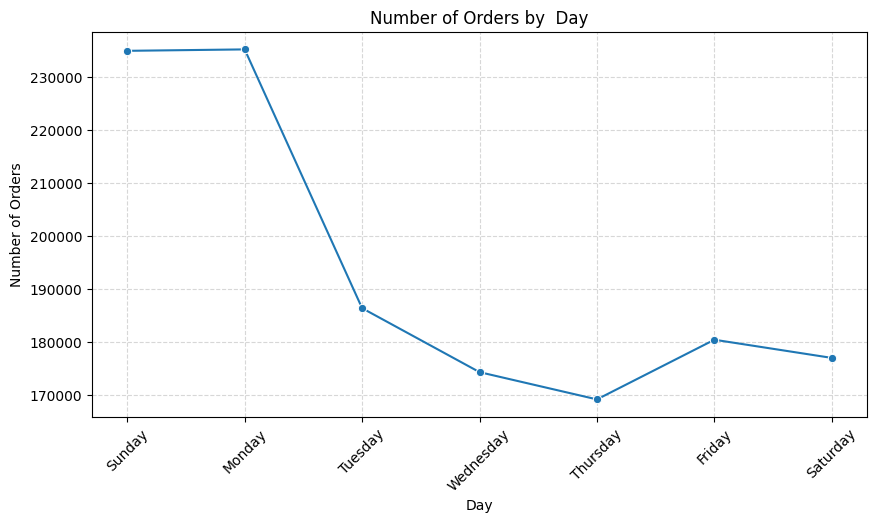

In [22]:
#Create the Graphic
days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_per_day,
    x="order_dow",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders by  Day")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.xticks(ticks=range(0,7), labels=days, rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

On observe dans la semaine que le pic de commande ce situe Samedi et Lundi, on a une grnade redecsende le mardi qui continue jusqu'a Jeudi, le nombre de commande réaugement le Vendredi, puis rediminue légérement le Samedi avant le pic du dimanche.

Déductions:

Les clients semble priviligié le dimanche et le lundi pour faire leur courses de la semaine

Insights:

On peut mettre en avant les nouveaux produits le dimanche et lundi pour augementer leur chance d'être commander et de faire un bon démarrage.
On peut aussi proposer des réduction sur des articles que le magazin veut destocker ces jours là, pour espérer profiter de l'effet d'achat groupé.

Nous pouver maintenant nous demander qu'elle est le comportement d'achat des client au cours de la journée

Voyons d'abord globalement le nombre de commande en fonction des heures de la journée

In [5]:
#Prepare Data 
orders_per_hour = (
    df_nextBuy
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)


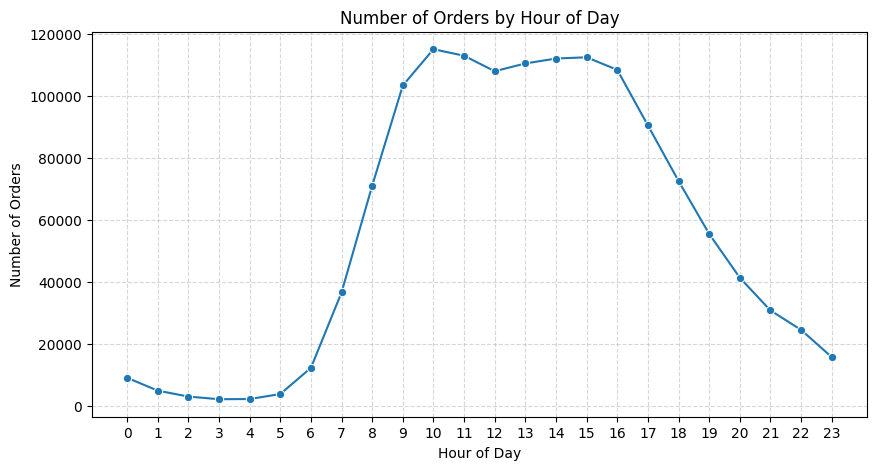

In [6]:
#Graphic of the number of orders in each hour of the day

plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_per_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le graphique montre qu'en moyenne à partir de 6 heures du matin les commandes augmentent, cela continue de manière exponentielle jusqu'à un pic à 10 h, puis on observe une stagnation jusqu'à 17 h :
À partir de 17 h, on observe une baisse jusqu'à 4 h du matin.
On peut se demander si cela est le cas pour tous les jours.

Ci-dessous seront donc les graphiques du nombre de commande par heure pour chaque jour

Dimanche

In [7]:
#Prepare Data (Sunday per hour)
df_sunday = df_nextBuy[df_nextBuy["order_dow"] == 0]
orders_sunday_hour = (
    df_sunday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

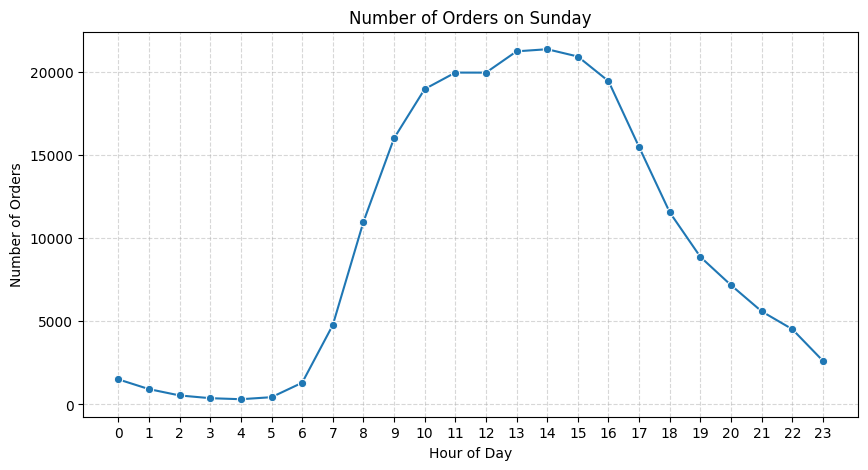

In [8]:
#The Graphic (Sunday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_sunday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Sunday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

On observe le dimanche une apogé déplacé en aprés midi sinon la courbe suis à peu près la même tendance que la courbe global

Lundi

In [9]:
#Prepare Data (Monday per hour)
df_monday = df_nextBuy[df_nextBuy["order_dow"] == 1]
orders_monday_hour = (
    df_monday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

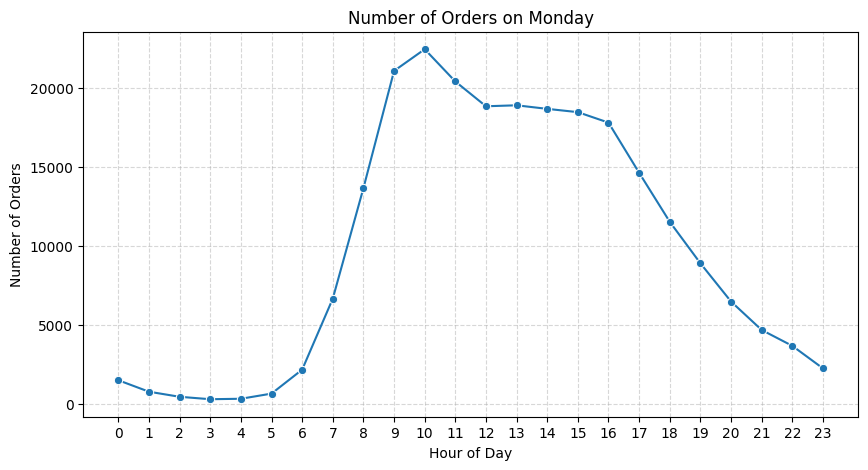

In [10]:
#The Graphic (Monday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_monday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Monday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le lundi le pic de commande  ce déplace le matin plus exactement a 10h puis redescend jusqu'a 12 où il stagne jusqu'a 16 h, puis le courbe suit un shémas habituelle.

Mardi

In [11]:
#Prepare Data (Tuesday per hour)
df_tuesday = df_nextBuy[df_nextBuy["order_dow"] == 2]
orders_tuesday_hour = (
    df_tuesday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

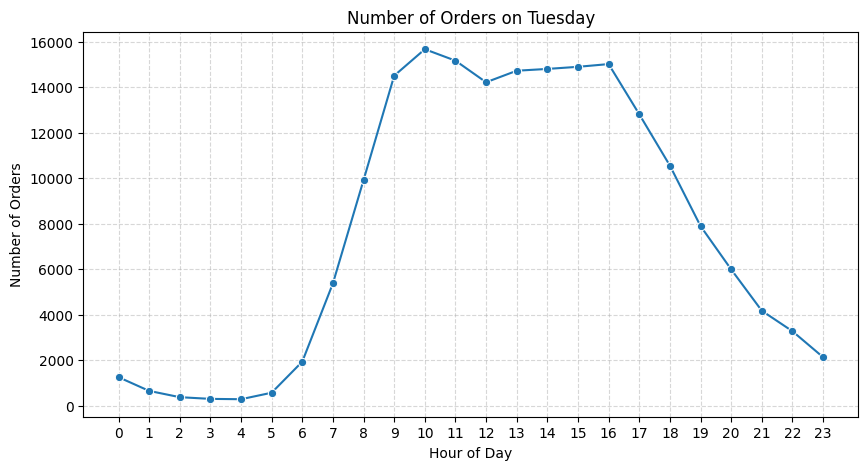

In [12]:
#The Graphic (Tuesday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_tuesday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Tuesday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le mardi l'apogé et le pic et aussi situé le matin mais la descente et moins fulgurante à midi que le lundi, par ailleurs après midi la courbe remonte légerement jusqu'a 16h ou elle suit une descente habituelle, a noté qu'il y'a comme vu précedament beaucoup moins de commande le Mardi que les 2 précedant jour de la semaine

Mercredi

In [13]:
#Prepare Data (Wednesday per hour)
df_wednesday = df_nextBuy[df_nextBuy["order_dow"] == 3]
orders_wednesday_hour = (
    df_wednesday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

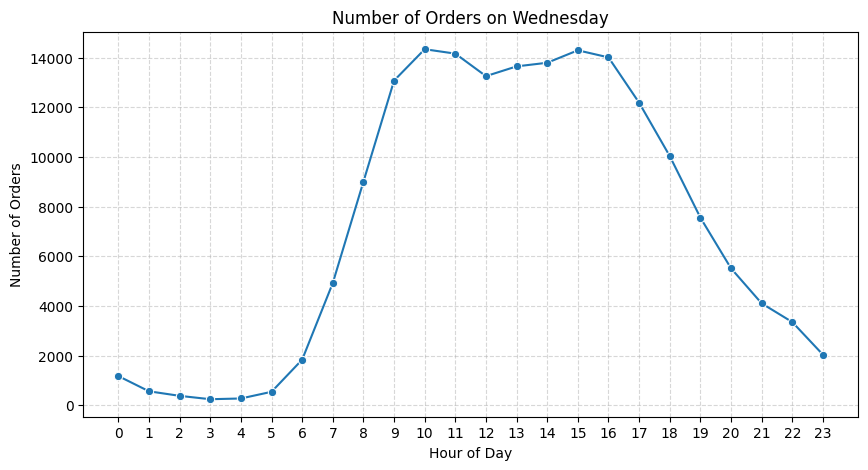

In [14]:
#The Graphic (Wednesday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_wednesday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Wednesday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le mercredi on Observe une courbe qui ressemble beaucoup à la courbe global avec toujours ce creux a midi.

Jeudi

In [15]:
#Prepare Data (Thursday per hour)
df_thursday = df_nextBuy[df_nextBuy["order_dow"] == 4]
orders_thursday_hour = (
    df_thursday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

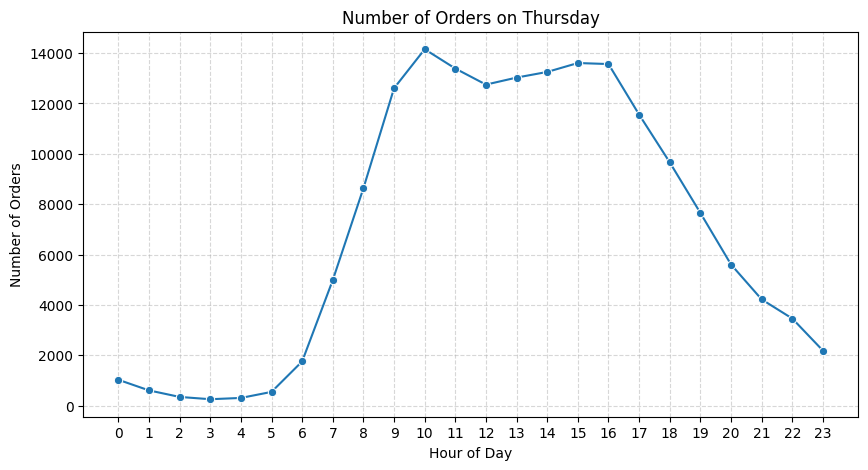

In [16]:
#The Graphic (Thursday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_thursday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Thursday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le jeudi on a encore ce pic de commande le matin vers 10h, avec le creux du midi et une remonter lente jusqu'a 17h puis redesente habituelle.

Vendredi

In [17]:
#Prepare Data (Friday per hour)
df_friday = df_nextBuy[df_nextBuy["order_dow"] == 5]
orders_friday_hour = (
    df_friday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

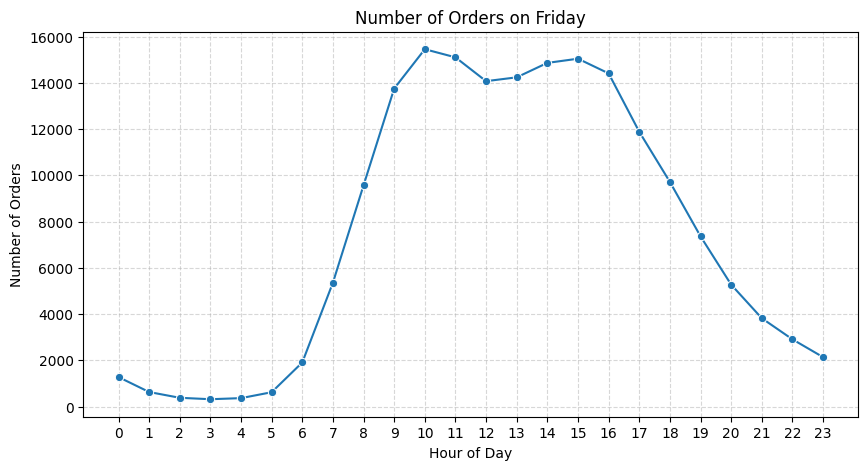

In [18]:
#The Graphic (Friday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_friday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Friday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le vendredi la différence entre le nombre de commande le matin et l'après midi et moins marquer, mais les clients on comme même plus tendance a commander la matin

Samedi

In [19]:
#Prepare Data (Saturday per hour)
df_saturday = df_nextBuy[df_nextBuy["order_dow"] == 6]
orders_saturday_hour = (
    df_saturday
    .groupby("order_hour_of_day")["order_id"]
    .nunique()
    .reset_index(name="num_orders")
)

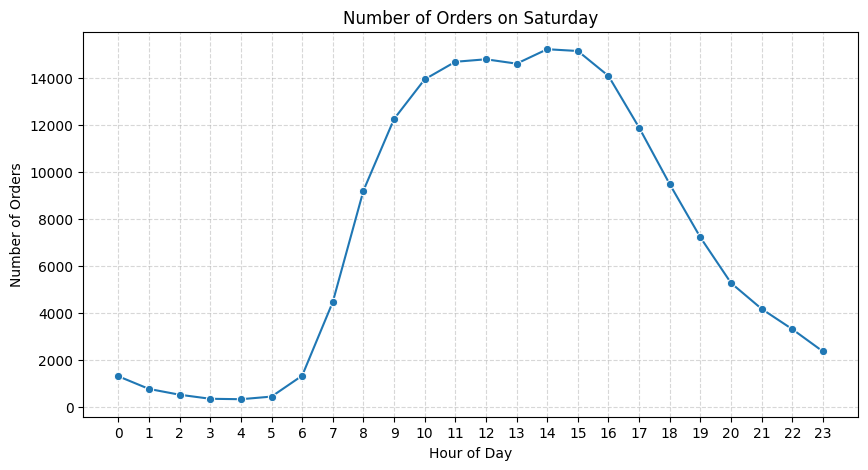

In [20]:
#The Graphic (Saturday per hour)
plt.figure(figsize=(10,5))

sns.lineplot(
    data=orders_saturday_hour,
    x="order_hour_of_day",
    y="num_orders",
    marker="o"
)

plt.title("Number of Orders on Saturday")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(0,24))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Observation:

Le samedi par contre comme le dimanche le pic de vente ce trouve l'aprés midi

Observation Global:

Il y'a trés souvent un creux à midi surtout en semaine, les clients commande plus le matin en semaine et plus l'après midi le week-end, on observe pas de grande différence ou de comportement exotique entre les jours. Il n'y a pas par exemple un pic ou une forte demande au milieu de la nuit.

Déduction:

Le creux aux alentour de midi et certainement dû à la pause déjeuner, la propotention à commander plus le matin la semaine et certainement lié aux activités spécifique a celle ci. Enfin on peut déduire que les gens priviligie le dernière jour du week-end ou le premier jour de la semaine pour faire leur course de la semaine.

Insight: 

Si l'on veut mettre en avant un produit, soit par une promotion soit par ça nouveauté et que la sortie de cette évenement et prévu en semaine il conviendrait mieux de la faire  un lundi matin. Par ailleuirs si l'on prévois une sortie le week-end il faudrait s'attendre a ce que les meuilleurs statistiques soit atteint le
dimanche après midi.